# Toy Speech Recognizer

In this homework assignment you will train and evaluate a toy speech recognizer that can recognize 'yes' and 'no'.  As we move into the latter half of the course, note that the assignments will have less and less hand holding.  The goal is for you to become more and more independent, so that you are ready to work independently on the final project.  This assignment should be done in pairs and only one submission needs to be submitted on Gradescope for each team.  In your submission, you should create a single .zip file that contains your jupyter notebook, audio data, annotation data, and generated prediction files.

Please indicate the team member names here: Korin Aldam-Tajima, Nick Daas

How many hours you each spent on this assignment: 8 (partner 1), 8 (partner 2)

This assignment will be broken down into 5 main sections:
1. Collect data & annotate (10 points)
2. Train model using manual annotations (20 points)
3. Perform inference on test data (20 points)
4. Infer strong labels on weakly labeled data (20 points)
5. Retrain model and evaluate on test data (20 points)

An additional 10 points will be based on how well organized, commented, and readable your code is.

In [342]:
%matplotlib inline

In [343]:
import numpy as np
import matplotlib.pyplot as plt
import librosa as lb
from pathlib import Path
from scipy.stats import multivariate_normal

### Part 1: Data Collection & Annotation

For the data collection, you will record 10 audio clips:
- Training data: 5 recordings.  Five of the audio recordings will be for training.  For these recordings, you should say a random sequence of ten yes's or no's.  For example, one recording might be 'yes no yes yes no no yes yes yes no'.  The recordings do not all have to have the same sequence of yes's and no's.  When recording your speaking, please include a variable-length silence in between each word.
- Test data: 5 recordings.  Five of the audio recordings will be for testing.  For these recordings, you should say a variable-length sequence of yes's and no's.  For example, one recording might be 'yes no' and another might be 'no yes yes no no yes no yes'.  Use a variety of different lengths in your sentences.  Again, please include silence in between each word.

All audio recordings should be done by a single person on a single device in the same environment (e.g. recorded on a cell phone in your dorm room).

Once you have recorded the audio, convert them to a format that librosa can read (e.g. wav or mp3) and put them in a folder entitled 'audio/'.  Name the files train1.mp3, train2.mp3, test1.mp3, test2.mp3, etc.

In [344]:
AUDIO_DIR = Path('audio') 
ext = '.wav' # audio format

In [345]:
def verifyAudioData(indir, file_ext):
    # verifies that all the needed audio files are present

    # check train files
    for i in range(5):
        curfile = Path(AUDIO_DIR, f'train{i+1}').with_suffix(ext)
        assert curfile.is_file(), f'Missing training file {curfile}'

    # check test files
    for i in range(5):
        curfile = Path(AUDIO_DIR, f'test{i+1}').with_suffix(ext)
        assert curfile.is_file(), f'Missing test file {curfile}'

    print('All required audio data files are present!')
    
    return

In [346]:
verifyAudioData(AUDIO_DIR, ext)

All required audio data files are present!


Next you will create two different kinds of annotations: weak labels and strong labels.  

**Weak labels**.  Create two annotation files for the weak labels.  The file train.transcription should look like:

train1.mp3|yes no no yes no yes no no yes no\
train2.mp3|no yes yes yes no no yes no yes no\
...\
train5.mp3|yes no yes yes no no no yes no yes

The file test.transcription should look like:

test1.mp3|yes no\
test2.mp3|no yes yes no yes\
...\
test5.mp3|yes no yes no no yes no yes yes yes

**Strong labels**.  Create one annotation file for train1.mp3 (only) containing strong labels.  The file train1.labels should be in the following format:

0.00 1.37 sil\
1.37 2.60 yes\
2.60 5.20 sil\
5.20 6.30 no\
6.30 8.10 sil\
...\
12.30 13.25 yes\
13.25 15.90 sil

For annotating timestamps, I recommend that you use Audacity.  Note that we are only annotating one file with strong labels because this process is time-consuming!

In [347]:
ANNOT_DIR = Path('annot')
train_transcripts = Path(ANNOT_DIR, 'train.transcription')
test_transcripts = Path(ANNOT_DIR, 'test.transcription')
train1_labels = Path(ANNOT_DIR, 'train1.labels')

In [348]:
def verifyAnnotations():
    # verifies that all of the needed annotation files are present

    assert train_transcripts.is_file(), f'Missing transcription file {train_transcripts}'    
    assert test_transcripts.is_file(), f'Missing transcription file {test_transcripts}'    
    assert train1_labels.is_file(), f'Missing label file {train1_labels}'
    print('All required annotation files are present!')
    
    return

In [349]:
verifyAnnotations()

All required annotation files are present!


Using the above format for your label file, you should be able to visualize your labels alongside the audio in Audacity by selecting File --> Import --> Labels.  An example is shown below.  This type of visualization will be useful in evaluating how accurate your alignments and predictions are.

![Snapshot](labels_snapshot.png)

**Graded**: Please include a similar visualization of your data below.  Make sure you include your image file in your submission!

![Snapshot](labels.png)

### Part 2: Model Training

In this part, you will train an HMM model based (only) on the label file for train1.mp3.  You must complete the implementations of the functions below.  No unit tests will be provided, though, so make sure to check your own work and verify that they are what you expect!

The function below extracts a feature called mel frequency cepstral coefficients.  Unlike chroma features, which focus on pitch (i.e. fine spectral structure), MFCCs focus on timbre (i.e. rough spectral structure) and are helpful for recognizing speech or distinguishing between different instruments.  You may use the librosa function [librosa.feature.mfcc](https://librosa.org/doc/latest/generated/librosa.feature.mfcc.html) with default arguments.

In [350]:
import librosa

In [351]:
def computeFeatures(audiofile):
    """
    This function extracts mel frequency cepstral coefficients (MFCCs) from a given audio file.
        
    Inputs
        - audiofile: filepath to the audio recording that you want to extract MFCC features from
        
    Outputs
        - O: an F x N array containing MFCC features, where F corresponds to different features and 
             N corresponds to different audio frames
        - hop: the hop size (in seconds) between adjacent frames
    """
    ### INSERT CODE BELOW ###

    hop = 512
    
    audio, sr = lb.load(audiofile, sr=22050)
    O = lb.feature.mfcc(y=audio, sr=sr, hop_length=hop, n_fft=2048)

    hop_sec = hop / sr
   
    return (O, hop_sec)

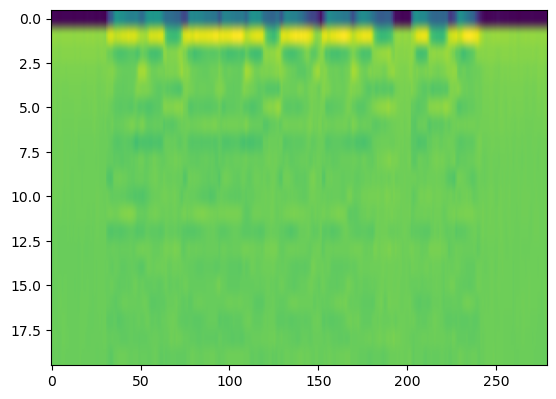

In [352]:
# plot the MFCCs for test1.wav
O, hop = computeFeatures("audio/train1.wav")
plt.imshow(O, aspect=10)


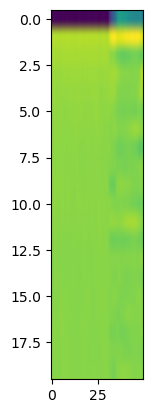

In [353]:
plt.imshow(O[:,:50], aspect=10)

In [354]:
print(O.min())
print(O.max())

-716.68585
212.38985


The function below constructs a mapping between the states and their numeric identifiers.  For ease of grading, please use the following mapping:
- sil -> 0
- Y -> 1
- EH -> 2
- S -> 3
- N -> 4
- OH -> 5

In [355]:
def getStateMapping():
    """
    Returns a mapping between the string and numeric representations of the six different states.
    
    Outputs
      - states: a list that contains the states (in order).  This allows you to map from the numeric identifier
        to the string representation (e.g. states[3])
      - stateStr2id: a dict that maps from the state string representation to its numeric identifier (e.g. stateStr2id['EH'])
    """
    ### INSERT CODE BELOW ###
    states = ['sil', 'Y', 'EH', 'S', 'N', 'OH']
    stateStr2id = {state: i for i, state in enumerate(states)}
    
    return (states, stateStr2id)

In [356]:
getStateMapping()

(['sil', 'Y', 'EH', 'S', 'N', 'OH'],
 {'sil': 0, 'Y': 1, 'EH': 2, 'S': 3, 'N': 4, 'OH': 5})

The function below converts a .labels file into a sequence of states per frame.  You may assume that states in a word have equal duration (e.g. if the word 'yes' lasts 1.2 seconds, you can assume that 'Y', 'EH', and 'S' each have duration 0.4 sec).

In [357]:
def getStatesFromLabelFile(labelfile, hopsize, str2id):
    """
    Reads in a label file and returns a sequence of states for each audio frame.  For any given word, it assumes
    that the constituent states all have equal duration.  For example, if the word 'yes' lasts 1.2 seconds, the constituent
    states 'Y', 'EH', and 'S' are assumed to each have duration 0.4 seconds.
    
    Inputs
      - labelfile: filepath to the .labels or .forcealign file 
      - hopsize: the hop size in seconds between adjacent audio frames
      - str2id: dict that maps from the state's string representation to its numeric representation

    Outputs
      - S: list containing the sequence of numeric states for each audio frame
    """
    ### INSERT CODE BELOW ###
    
    # label file format
    '''
    0.000000	1.152665	sil
    1.152665	1.886179	yes
    1.886179	3.038844	sil
    3.038844	3.499910	no
    '''
    with open(labelfile, 'r') as f:
        lines = f.readlines()
    S = []
    for line in lines:
        parts = line.split()
        start = float(parts[0])
        end = float(parts[1])

        frames = (end - start) // hopsize

        state = parts[2]
        states_to_syllable = {
            'sil': ['sil'],
            'yes':['Y', 'EH', 'S'],
            'no':['N', 'OH']
        }
        syllables = states_to_syllable[state]

        for syllable in syllables:
            syllable_repeat = int(np.round(frames / len(syllables)))

            for _ in range(syllable_repeat):
              S.append(str2id[syllable])
    return S

This is a good place to verify that your functions are producing correct outputs:

In [358]:
O, hop = computeFeatures(Path(AUDIO_DIR, 'train1.wav'))
states, stateStr2id = getStateMapping()
S = getStatesFromLabelFile(train1_labels, hop, stateStr2id)
print(S)
print(np.array(S).shape)
print(O.shape)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 0, 0, 0, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 0, 0, 0, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
(266,)
(20, 279)


In [359]:
np.where(np.array(S) == 1)

(array([ 49,  50,  51,  52,  53,  54,  55, 106, 107, 108, 109, 110, 111,
        163, 164, 165, 166, 167, 168, 194, 195, 196, 197, 198, 199]),)

In [360]:
np.where(np.array(S) == 0)

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  46,  47,  48,  70,  71,
         72,  89,  90,  91, 104, 105, 124, 125, 126, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 160, 161, 162, 181, 182, 183, 184, 185,
        186, 187, 188, 189, 190, 191, 192, 193, 212, 213, 214, 215, 216,
        227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239,
        240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252,
        253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265]),)

In [361]:
print(stateStr2id)

{'sil': 0, 'Y': 1, 'EH': 2, 'S': 3, 'N': 4, 'OH': 5}


The function below trains an HMM given a list of observations (i.e. MFCC feature matrices) and corresponding states.  A few helpful tips:
- In this part of the assignment, you will only train the model on the train1.mp3 example, but your function below should be able to handle multiple training examples so that you can reuse this function in part 5.
- You may assume that recordings always begin in the silent state.
- You should assume that the emission probability model is a multivariate Gaussian model.
- You should decompose this function and define other sub-functions as needed to keep your code neat and organized.

In [362]:
def getstatetransitionmat(S_list, states):

    A = np.zeros((len(states), len(states)), dtype=float)

    for seq in S_list:
        for i in range(len(seq) - 1):
            curr_state = seq[i]
            next_state = seq[i+1]
            A[curr_state, next_state] += 1

    # normalize rows to convert counts -> probabilities
    # rows with no outgoing transitions produce NaNs in A, which breaks Viterbi
    for i in range(len(states)):
        if A[i].sum() == 0:
            A[i, i] = 1.0  # unseen state: self-loop so rows stay valid
    row_sums = A.sum(axis=1, keepdims=True)
    A = A / row_sums
    return A 



In [363]:
A = getstatetransitionmat([S], states)
print(A)

[[0.9137931  0.03448276 0.         0.         0.05172414 0.        ]
 [0.         0.84       0.16       0.         0.         0.        ]
 [0.         0.         0.84       0.16       0.         0.        ]
 [0.16       0.         0.         0.84       0.         0.        ]
 [0.         0.         0.         0.         0.83783784 0.16216216]
 [0.16216216 0.         0.         0.         0.         0.83783784]]


In [364]:
def state_means(O_list, S_list, states):
    # average across all the frames for each mfcc set for each state
    O_cat_parts = []
    S_cat_parts = []
    for O, S in zip(O_list, S_list):
        O = np.asarray(O)
        S = np.asarray(S)
        n = min(O.shape[1], S.shape[0])
        O_cat_parts.append(O[:, :n])
        S_cat_parts.append(S[:n])

    O_cat = np.hstack(O_cat_parts)
    S_cat = np.concatenate(S_cat_parts)

    numstates = len(states)
    D = O_cat.shape[0]
    overall_mean = np.zeros((numstates, D))
    global_mean = O_cat.mean(axis=1)

    for s in range(numstates):
        mask = S_cat == s
        if not np.any(mask):
            overall_mean[s, :] = global_mean
        else:
            overall_mean[s, :] = O_cat[:, mask].mean(axis=1)

    return overall_mean

In [365]:
a = [1, 2, 3, 4, 54, 6, 7, 8, 9, 10]
idxs = [0,2,4]
a = np.array(a)
a[idxs]

array([ 1,  3, 54])

In [366]:
meanvec=state_means([O,O], [S,S], states)

print(meanvec)



[[-5.53837524e+02  7.33091812e+01  2.62952385e+01  2.26378784e+01
   9.37026024e+00  1.55281000e+01  8.81942081e+00 -3.27725172e-01
   5.83290720e+00  3.24799514e+00  5.83061552e+00  1.12251329e+01
  -5.34933567e-01  5.63677549e+00  8.10091913e-01  1.38907015e+00
   2.94460988e+00 -1.94139564e+00 -7.43279904e-02  4.42542136e-01]
 [-4.25548157e+02  1.22953995e+02 -8.78446579e+00  4.26101112e+01
   2.29685059e+01 -5.92057514e+00  1.18284445e+01 -2.93071671e+01
   3.47639656e+00 -1.03963041e+00 -5.61236715e+00  9.31903660e-01
  -8.96462631e+00  9.67454338e+00 -6.40613842e+00 -1.03952444e+00
   3.47690797e+00  5.83413899e-01 -6.07388687e+00  2.44324040e+00]
 [-3.23006073e+02  1.39500137e+02 -2.44448586e+01  3.19040432e+01
   9.25489426e+00 -1.76881542e+01 -1.28207159e+00 -3.59979477e+01
  -1.61821473e+00  2.46566248e+00  8.96313190e-01  3.71724892e+00
  -1.68088226e+01  7.19604492e+00  3.67902446e+00 -5.40335464e+00
  -1.11831474e+01 -3.39741278e+00 -1.89480364e+00 -4.21445465e+00]
 [-3.39

In [367]:
def get_covars(O_list, S_list, means):

    cov_matrices = []

    for O, S in zip(O_list, S_list):
        O = np.asarray(O)
        S = np.asarray(S).ravel()

        n = min(O.shape[1], S.shape[0])
        O = O[:, :n]
        S = S[:n]

        cov_matrix = []

        for state in range(len(means)):
            idxs = np.flatnonzero(S == state)
            idxs = np.clip(idxs, 0, n - 1)
            if idxs.size < 2:
                cov_matrix.append(np.eye(O.shape[0]) * 1e-6)
                continue
            O_state = O[:, idxs]

            cov_state = np.cov(O_state) # covariance matrix of the ith state. By default, it assumes each row represents a variable and each column represents an observation
            
            cov_matrix.append(cov_state)

            # check if its a valied covariance matrix
            if np.linalg.det(cov_state) == 0:
                print(f"Invalid covariance matrix for state {state}")
                print(cov_state)
        
        cov_matrices.append(cov_matrix)

    
    overall_cov_matrix = np.mean(cov_matrices, axis=0)

    return overall_cov_matrix

In [368]:
get_covars([O,O], [S,S], meanvec)

array([[[ 2.54558845e+04,  3.14760356e+03, -3.43110110e+03, ...,
         -8.45082350e+02, -6.11811657e+02, -1.45443117e+02],
        [ 3.14760356e+03,  7.14421025e+03, -2.37620625e+03, ...,
         -4.81083757e+02, -5.94640288e+02,  2.47005610e+02],
        [-3.43110110e+03, -2.37620625e+03,  1.22803439e+03, ...,
          2.10399930e+02,  2.39682481e+02, -6.22304892e+01],
        ...,
        [-8.45082350e+02, -4.81083757e+02,  2.10399930e+02, ...,
          7.05859692e+01,  5.29090567e+01,  1.84285016e+00],
        [-6.11811657e+02, -5.94640288e+02,  2.39682481e+02, ...,
          5.29090567e+01,  7.14903163e+01, -1.12252646e+01],
        [-1.45443117e+02,  2.47005610e+02, -6.22304892e+01, ...,
          1.84285016e+00, -1.12252646e+01,  3.46753358e+01]],

       [[ 2.68861351e+04,  5.49142970e+03, -5.31166657e+03, ...,
         -5.60454664e+02, -1.42552792e+03, -3.63392298e+02],
        [ 5.49142970e+03,  2.96418089e+03, -1.46160479e+03, ...,
         -1.80562386e+02, -4.06457692e

In [369]:
np.array(get_covars([O], [S], meanvec)).shape

(6, 20, 20)

In [370]:
def trainHMM(O_list, S_list, states):
    """
    Trains an HMM given a list of observations and corresponding states.  The HMM assumes a multivariate Gaussian
    emission probability model.

    Inputs
      - O_list: a list of matrices, where each matrix contains the MFCC coefficients for a single training recording
      - S_list: a list of arrays, where each array specifies the states in each audio frame for a single training recording
      - states: a list specifying the states in their string representation
      
    Outputs
      - A: the state transition probability matrix
      - pi: the distribution of the initial state
      - means: a matrix where each row specifies the mean of the distribution for a single state
      - covars: a 3D tensor where the first index specifies a state, and the remaining two indices specify the covariance 
        matrix for the state's distribution
    """
    ### INSERT CODE BELOW ###
    pi = [1, 0, 0, 0, 0, 0] # initial state distribution (always start in 'sil')     

    A = getstatetransitionmat(S_list, states)                           
    means = state_means(O_list, S_list, states)
    covars = get_covars(O_list, S_list, means)
    
    return (A, pi, means, covars)

Use the functions defined above to train an HMM model on the train1.labels file (only).  For grading purposes, please print out the following variables (and make sure your submitted notebook is showing the values): 
- the state transition probability matrix A
- the means for all six states
- the covariance matrix for 'sil'

In [371]:
### INSERT AS MANY CELLS AS NEEDED BELOW ###

O, hop = computeFeatures(Path(AUDIO_DIR, 'train1.wav'))
states, stateStr2id = getStateMapping()
S = getStatesFromLabelFile(train1_labels, hop, stateStr2id)
A, pi, means, covars = trainHMM([O], [S], states)

**Graded**: Print out A below

In [372]:
A

array([[0.9137931 , 0.03448276, 0.        , 0.        , 0.05172414,
        0.        ],
       [0.        , 0.84      , 0.16      , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.84      , 0.16      , 0.        ,
        0.        ],
       [0.16      , 0.        , 0.        , 0.84      , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.83783784,
        0.16216216],
       [0.16216216, 0.        , 0.        , 0.        , 0.        ,
        0.83783784]])

**Graded**: Print out the state distribution means below

In [373]:
means

array([[-5.53837646e+02,  7.33091888e+01,  2.62952480e+01,
         2.26378803e+01,  9.37026405e+00,  1.55281010e+01,
         8.81942177e+00, -3.27725351e-01,  5.83290720e+00,
         3.24799466e+00,  5.83061695e+00,  1.12251329e+01,
        -5.34933209e-01,  5.63677645e+00,  8.10092032e-01,
         1.38907027e+00,  2.94461036e+00, -1.94139516e+00,
        -7.43280724e-02,  4.42542195e-01],
       [-4.25548157e+02,  1.22953972e+02, -8.78446388e+00,
         4.26101112e+01,  2.29685116e+01, -5.92057562e+00,
         1.18284473e+01, -2.93071632e+01,  3.47639656e+00,
        -1.03963029e+00, -5.61236811e+00,  9.31903660e-01,
        -8.96462440e+00,  9.67454433e+00, -6.40613699e+00,
        -1.03952456e+00,  3.47690797e+00,  5.83413839e-01,
        -6.07388735e+00,  2.44324040e+00],
       [-3.23006073e+02,  1.39500137e+02, -2.44448528e+01,
         3.19040375e+01,  9.25489426e+00, -1.76881523e+01,
        -1.28207159e+00, -3.59979477e+01, -1.61821473e+00,
         2.46566248e+00,  8.9

**Graded**: Print out the covariance matrix for 'sil' below

In [374]:
covars[0]

array([[ 2.54558845e+04,  3.14760356e+03, -3.43110110e+03,
        -1.27734441e+03, -1.59961328e+03, -9.05921739e+02,
        -6.19736639e+02, -1.88984126e+03, -4.94021093e+02,
        -6.19360587e+02, -6.49033288e+02,  6.60671260e+02,
        -9.20707484e+02,  3.50812384e+02, -5.08579579e+02,
        -5.19786197e+02, -1.31217336e+02, -8.45082350e+02,
        -6.11811657e+02, -1.45443117e+02],
       [ 3.14760356e+03,  7.14421025e+03, -2.37620625e+03,
        -9.79736420e+02,  8.61021943e+02, -1.62902560e+03,
         5.89983552e+02, -6.23651056e+02, -5.99100851e+02,
        -4.27399547e+02, -5.80849090e+02,  2.78997980e+02,
        -3.09721866e+02, -5.20165080e+02, -5.07444636e+02,
        -2.62147855e+02,  1.50606154e+01, -4.81083757e+02,
        -5.94640288e+02,  2.47005610e+02],
       [-3.43110110e+03, -2.37620625e+03,  1.22803439e+03,
         3.72527171e+02, -1.46190331e+02,  6.14834940e+02,
        -1.29520603e+02,  4.26132533e+02,  2.53988708e+02,
         1.42026261e+02,  2.3

### Part 3: Inference

In this part, we will use our trained model from part 2 to estimate the state sequence on test recordings.  You must complete the implementations of the functions below.  Again, no unit tests will be provided, so make sure to check your own work!

The function below calculates a pairwise similarity matrix, assuming a Gaussian emission probability model.  You may use the scipy implementation of [multivariate_normal](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html) in your implementation.

In [375]:
def calcSimilarity_multivariateGaussian(O, means, covars):
    """
    Calculates the matrix of likelihoods for a sequence of observations and a set of multivariate Gaussian models.

    Inputs
      - O: an D x N observation matrix, where D is the dimensionality of the feature representation and N is the number
        of observations
      - means: an M x D matrix specifying the distribution means, where M is the number of multivariate Gaussian models 
      - covars: an M x D x D array specifying the distribution covariance matrices, where the first index specifies the model
        and the remaining two indices specify the model's covariance matrix

    Outputs
      - probs: a M x N matrix specifying model likelihoods, where M corresponds to the different models and where N corresponds
        to the different observations
    """

    # first make sure O and S have the same number of frames. truncate O to the length of S.
    # O = O[:, :len(S)] 

    O = np.asarray(O)
    M = means.shape[0]
    N = O.shape[1]

    probs = np.zeros((M, N))

    for i in range(M):
        # each row i: 
        probs[i] = multivariate_normal.pdf(O.T, mean=means[i], cov=covars[i], allow_singular=True)

    return probs


In [376]:
prob = calcSimilarity_multivariateGaussian(O, means, covars).shape

The function below implements the Viterbi algorithm from scratch.  Since there are lots of implementations of Viterbi online, you should not consult any direct implementations.  If you are unable to complete this part on your own, you may consult an online implementation for a grade deduction.  If you do so, please cite the resource and describe the extent of the assistance so that points may be deducted appropriately.

**Graded**: Please cite any resources you consulted in implementing the function below, and the extent of the assistance: 

\<PUT RESPONSE HERE\>

In [377]:
def backtrace(D, B, endpoint_row):
    '''
    Backtraces through the cumulative cost matrix D.
    
    Arguments:
    D -- cumulative cost matrix
    B -- backtrace matrix
    endpoint_row -- the row index of the endpoint of the path
    
    Returns:
    path -- a python list of (row, col) coordinates for the optimal path.
    '''

    path = []

    ### START CODE BLOCK ###

    M, N = D.shape

    start = (endpoint_row, N-1)
    path.append(start)

    current_state = endpoint_row

    for col in range(N-1, 0, -1): # each column fills in one back
        best_state = B[current_state, col]
        path.append((best_state, col-1))
        current_state = best_state

    path = np.array(path)
    path = np.flip(path, axis=0) # reverse the path to start from the first column

    ### END CODE BLOCK ###
    
    return path

In [378]:
def viterbi(prob, A, pi):
    """
    Inputs
      - prob: a M x N matrix specifying model likelihoods, where M is the number of models and N is the number of observations
      - A: an M x M transition probability matrix
      - pi: a length M array specifying the initial state probability distribution
        
    Outputs
      - S_est: the estimated sequence of (numeric) states
    """
    ### INSERT CODE BELOW ###

    # step 1: probs, done.

    # step 2: compute the cumulative path score matrix and backtrace matrix

    M, N = prob.shape
    D = np.full(prob.shape, -np.inf, dtype=float)
    B = np.zeros(prob.shape, dtype=np.int8)

    # initialize first column
    with np.errstate(divide='ignore'):
      D[:, 0] = np.log(pi) + np.log(prob[:, 0])

    # fill D in
    A = np.asarray(A, dtype=float)

    for col in range(1, N):
        for row in range(M):
            best_score = -np.inf
            best_l = 0

            for l in range(M):
                with np.errstate(divide='ignore'):
                  score = D[l, col - 1] + np.log(A[l, row]) + np.log(prob[row, col]) # recurrence relation from lecture

                if score > best_score:
                    best_score = score
                    best_l = l

            D[row, col] = best_score
            B[row, col] = best_l

    # step 3: identify endpoint
    endpoint_row = np.argmax(D[:, -1])

    # step 4: backtrace
    path = backtrace(D, B, endpoint_row)
    path = np.array(path)

    S_est = path[:,0] # first column of path is the state sequence

    return S_est



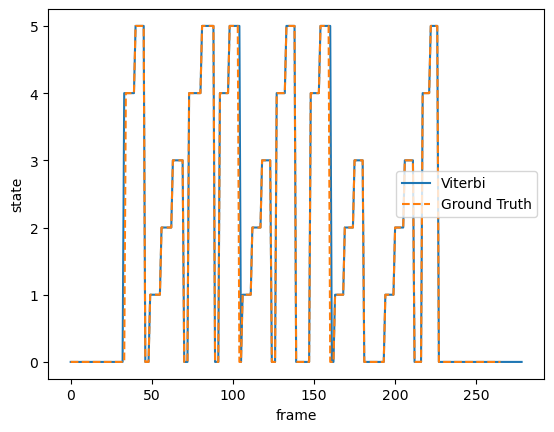

In [379]:
# train
train1_labels = Path(ANNOT_DIR, 'train1.labels')
O, hop = computeFeatures(Path(AUDIO_DIR, 'train1.wav'))
states, stateStr2id = getStateMapping()
S = getStatesFromLabelFile(train1_labels, hop, stateStr2id)
A, pi, means, covars = trainHMM([O], [S], states)

# inference
prob = calcSimilarity_multivariateGaussian(O, means, covars)
S_est = viterbi(prob, A, pi)

plt.plot(S_est)
plt.plot(S, linestyle='--')
plt.legend(['Viterbi', 'Ground Truth'])
plt.xlabel('frame')
plt.ylabel('state')
plt.show()

Using the two functions above, estimate the state sequence for each test recording and generate the corresponding .labels file (it can have a different extension but should have the same format so as to be readable by Audacity).  Include a visualization of your estimated states alongside the audio in Audacity (as shown above).  You may use as many code cells as needed, and be sure to decompose your code appropriately!

In [380]:
def train_model(file_num):
    # train
    train1_labels = Path(ANNOT_DIR, f'train{file_num}.labels')
    O, hop = computeFeatures(Path(AUDIO_DIR, f'train{file_num}.wav'))
    states, stateStr2id = getStateMapping()
    S = getStatesFromLabelFile(train1_labels, hop, stateStr2id)
    A, pi, means, covars = trainHMM([O], [S], states)
    return A, O, S, pi, means, covars

In [381]:
# train
train1_labels = Path(ANNOT_DIR, 'train1.labels')
O, hop = computeFeatures(Path(AUDIO_DIR, 'train1.wav'))
states, stateStr2id = getStateMapping()
S = getStatesFromLabelFile(train1_labels, hop, stateStr2id)
A, pi, means, covars = trainHMM([O], [S], states)

In [382]:
def inference(file_num):
    # inference
    O, hop = computeFeatures(Path(AUDIO_DIR, f'test{file_num}.wav'))
    prob = calcSimilarity_multivariateGaussian(O, means, covars)
    S_est = viterbi(prob, A, pi)
    return S_est


In [383]:
# test inference on test2.wav
# inference
inference(2)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0])

Wow it's really bad without forced alignment.

In [384]:
def estimate_state_sequence(file_num, A, pi, means, covars):
    # inference
    O, hop = computeFeatures(Path(AUDIO_DIR, f'test{file_num}.wav'))
    prob = calcSimilarity_multivariateGaussian(O, means, covars)
    S_est = viterbi(prob, A, pi)

    # state counting
    i = 1 # start 
    count = 1
    frame_counts = [] # counts for each state
    states_idxs = [] # each state in the estimation, without repeats. 0 0 0 0 --> 0,  1 1 1 ---> 1, etc.

    while i < len(S_est): # iterate until at the end of the states
        current_state = S_est[i]
        prev_state = S_est[i-1]
        # count how many of the same state there are
        # note: the first state is counted already, then we add one for every same state after.
        if current_state == prev_state: 
            count += 1 # e.g. if index 0 and 1 have the same state, count = 1 (+1) = 2 
        else:
            frame_counts.append(count) # e.g. if index 0 and 1 didn't have the same state, don't add anything. count=1 gets appended.
            states_idxs.append(prev_state) 
            count = 1
        i += 1 

        # convert to syllables
        states_transcription = [states[idx] for idx in states_idxs]

    return frame_counts, states_transcription, hop

In [385]:
def create_file(file_num, start_times, end_times, states_transcription, extension):
    # .vlabel filename
    vlabel_filename = f"annot/test{file_num}.{extension}"

    # create the file
    with open(vlabel_filename, "w") as f:
        for i, s in enumerate(states_transcription):
            # 0.000000	1.152665	sil       is the format.
            f.write(f"{start_times[i]:.6f}\t{end_times[i]:.6f}\t{s}\n")

In [386]:
### INSERT AS MANY CELLS AS NEEDED BELOW ###
import os

states, stateStr2id = getStateMapping()

#loop through each test file and create a .vlabel file
for i in range(5): 
    file_num = i + 1
    frame_counts, states_transcription, hop = estimate_state_sequence(file_num, A, pi, means, covars)

    # map number of frames to time
    end_times = np.cumsum(frame_counts) * hop
    start_times = np.concatenate(([0], end_times[:-1]))

    create_file(file_num, start_times, end_times, states_transcription, "vlabel")

Comment on what you observe in your estimated state sequence, and propose some ideas on how you might improve the system.

**Graded**: 


Observations: It looks like it picks up that there exists a signal difference between silence and a word. However, cannot differentiate between yes and no.

Improvements: Since it was only trained on train1.wav, maybe a variety of training data will provide more variance in how my ways of saying yes and no transition within the transition matrix. 

This could be done a variety of ways:
- add noise to the original signal around yes and no so they are interpreted more fuzzily.
- take weak labels for more training data and guess 

![Snapshot](pre-FA.png)

### Part 4: Forced Alignment

In this part, you will perform forced alignment to determine the correspondence between the states in a given word-level transcription and the corresponding audio recording.  Your goal is to implement the function below, and then use it to determine the state-level alignment for train1.mp3.  Make sure to decompose your function appropriately!

In [387]:
def forceAlignCalcSimilarity(O, S, means, covars):

    # first make sure O and S have the same number of frames. truncate O to the length of S.
    # O = O[:, :len(S)] 

    S = np.array(S)
    O = np.array(O)

    D = S.shape[0]
    N = O.shape[1]

    probs = np.zeros((D, N)) # length of state sequence rows x number of frames

    for i in range(D):
        # each row i: 
        probs[i] = multivariate_normal.pdf(O.T, mean=means[i], cov=covars[i], allow_singular=True)

    return probs


In [388]:
def forceAlign_backtrace(D, B, endpoint_row):
    '''
    Backtraces through the cumulative cost matrix D.
    
    Arguments:
    D -- cumulative cost matrix
    B -- backtrace matrix
    endpoint_row -- the row index of the endpoint of the path
    
    Returns:
    path -- a python list of (row, col) coordinates for the optimal path.
    '''

    path = []

    ### START CODE BLOCK ###

    M, N = D.shape

    start = (endpoint_row, N-1)
    path.append(start)

    current_row = endpoint_row

    # Moves:
    # if B is 0, diagonal 
    # if B is 1, horizontal

    
    for col in range(N - 1, 0, -1):
        if B[current_row, col] == 0:
            path.append((current_row - 1, col - 1))
            current_row = current_row - 1
        else:
            path.append((current_row, col - 1))

    path = np.array(path)
    path = np.flip(path, axis=0) # reverse the path to start from the first column

    ### END CODE BLOCK ###
    
    return path

    

In [ ]:
def forcedAlignment(audiofile, word_transcript, model, stateStr2id):
    """
    Performs forced alignment between a given word-level transcription and the corresponding audio recording.

    Inputs
      - audiofile: filepath to the audio recording
      - word_transcript: a string indicating the word-level transcription.  The transcription should only
        contain 'yes' and 'no'; the function will raise an error if it contains anything other than these two words
      - model: tuple of (A, pi, means, covars) specifying the trained HMM
      - stateStr2id: a dict that maps from the state string representation to its numeric identifier (e.g. stateStr2id['EH'])

    Output
      - alignment: an array specifying the coordinates of the forced alignment (frame, state_id) pairs
    """
    ### INSERT CODE BELOW ###


    A, pi, means, covars = model

    words = word_transcript.split()
    states_to_syllable = {
        'yes': ['sil', 'Y', 'EH', 'S'],
        'no':  ['sil', 'N', 'OH']
    }

    # Build expanded state sequence (with final silence)
    seq = []
    for w in words:
        if w not in states_to_syllable:
            raise ValueError(f"Unsupported word in transcript: {w}")
        seq.extend(states_to_syllable[w])
    seq.append('sil')

    IDseq = [stateStr2id[s] for s in seq]

    # Features: O is (feat_dim, num_frames)
    O, hop = computeFeatures(audiofile)
    num_states = len(IDseq)
    num_frames = O.shape[1]

    # State–frame log-likelihoods
    probs = np.zeros((num_states, num_frames))
    for st, state_id in enumerate(IDseq):
        probs[st, :] = multivariate_normal.logpdf(
            O.T,
            mean=means[state_id],
            cov=covars[state_id],
            allow_singular=True
        )

    eps = 1e-8

    # Dynamic programming matrices
    D = np.full((num_states, num_frames), -np.inf)
    B = np.zeros((num_states, num_frames), dtype=int)

    # Initialize first 
    D[0, 0] = probs[0, 0]

    # Initialize first column
    for i in range(1, num_states):
        D[i, 0] = D[i-1, 0] + probs[i, 0] + np.log(A[IDseq[i-1], IDseq[i]] + eps)
        B[i, 0] = 0  # diagonal

    # Initialize first row
    for j in range(1, num_frames):
        D[0, j] = D[0, j-1] + probs[0, j] + np.log(A[IDseq[0], IDseq[0]] + eps)
        B[0, j] = 1  # horizontal

    # Fill D for i >= 1, j >= 1
    for i in range(1, num_states):
        for j in range(1, num_frames):
            diag = D[i-1, j-1] + probs[i, j] + np.log(A[IDseq[i-1], IDseq[i]] + eps)
            horiz = D[i, j-1] + probs[i, j] + np.log(A[IDseq[i],   IDseq[i]] + eps)

            if diag >= horiz:
                D[i, j] = diag
                B[i, j] = 0  # diagonal
            else:
                D[i, j] = horiz
                B[i, j] = 1  # horizontal

    # Backtrace
    alignment = []
    s = num_states - 1
    t = num_frames - 1           # last frame

    while True:
        alignment.append((IDseq[s], t))  #as long as something is being appended run

        if t == 0 and s == 0:  #stop once backtraced to first state,frame
            break

        prev = B[s, t]

        if prev == 0:  #if previous state in B is 0, move diagonally 
            s -= 1
            t -= 1
        else:          #if previous state in B is 1, move horizontally
            t -= 1

        if s < 0 or t < 0: #Break Safe 
            break

    alignment.reverse()
    if len(alignment) != num_frames:
        raise RuntimeError(
            "forcedAlignment backtrace incomplete (path shorter than MFCC frames). "
            f"len(alignment)={len(alignment)}, num_frames={num_frames}. "
            "This causes label times to drift vs the frame plot; fix DP/backtrace."
        )
    return np.array(alignment), IDseq, O, hop

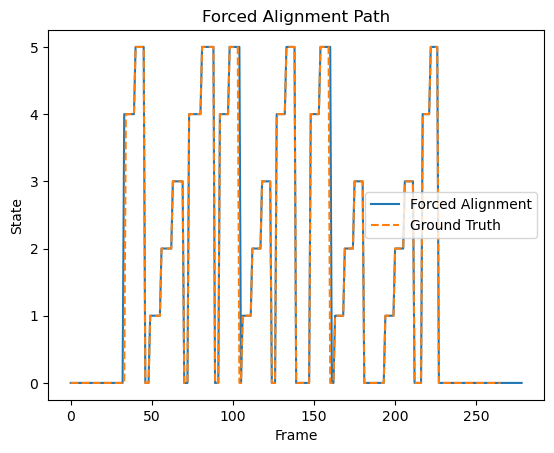

In [390]:
path, IDseq, O_fa, hop_fa = forcedAlignment(Path(AUDIO_DIR, 'train1.wav'), 'no yes no no yes no no yes yes no', (A, pi, means, covars), stateStr2id)

# print(path)

y = path[:,0]
x = path[:,1]

plt.plot(x, y, label='Forced Alignment')
plt.plot(S, label='Ground Truth', linestyle='--')
plt.xlabel('Frame')
plt.ylabel('State')
plt.title('Forced Alignment Path')
plt.legend()
plt.show()



Once you have implemented the forced alignment function above, use it to estimate the state-level alignment for train1.mp3.  Visualize the predicted alignment alongside the audio in Audacity, and also include the word-level alignment from part 1 (that you manually created).  Comment on how the forced alignment method improves the quality of the alignment.

In [391]:
def forceAlign_estimate_state_sequence(file_num, word_transcript):
    path, IDseq, O, hop = forcedAlignment(
        Path(AUDIO_DIR, f"train{file_num}.wav"),
        word_transcript,
        (A, pi, means, covars),
        stateStr2id,
    )
    if len(path) != O.shape[1]:
        raise RuntimeError(
            f"path/O mismatch: len(path)={len(path)}, O.shape[1]={O.shape[1]}"
        )
    

    # path[:, 0] is the HMM state id (sil y eh ...)
    state_ids = path[:, 0].astype(int)
    # if the state is 1,2,3, make it 1 --> yes
    # if the state is 4,5, make it 2 --> no
    state_ids = np.where(np.isin(state_ids, [1, 2, 3]), 1, state_ids)
    state_ids = np.where(np.isin(state_ids, [4, 5]), 2, state_ids)

    frame_counts = []
    states_idxs = []
    count = 1
    i = 1

    # count how many of the same state there are
    while i < len(state_ids):
        if state_ids[i] == state_ids[i - 1]:
            count += 1
        else:
            frame_counts.append(count)
            states_idxs.append(int(state_ids[i - 1]))
            count = 1
        i += 1
    frame_counts.append(count)
    states_idxs.append(int(state_ids[-1]))

    states = ['sil', 'yes', 'no']

    states_transcription = [states[idx] for idx in states_idxs]
    return frame_counts, states_transcription, hop, O

In [392]:
def get_forcealign_file(file_num):
    with open(Path(ANNOT_DIR, "train.transcription")) as f:
        line = next(ln for ln in f if ln.strip().startswith(f"train{file_num}.wav"))
        word_transcript = line.split("|", 1)[1].strip()
        print(word_transcript)

        frame_counts, states_transcription, hop, O = forceAlign_estimate_state_sequence(
            file_num, word_transcript
        )

        print(states_transcription)

        # convert frame counts to time
        audio, sr = lb.load(Path(AUDIO_DIR, f"train{file_num}.wav"))
        audio_duration = len(audio) / float(sr)
        N = O.shape[1]
        if sum(frame_counts) != N:
            raise RuntimeError(f"frame_counts sum {sum(frame_counts)} != O.shape[1] {N}")
        HOP_LENGTH, N_FFT = 512, 2048
        edges = np.concatenate([[0], np.cumsum(frame_counts)])
        t_edges = lb.frames_to_time(edges, sr=sr, hop_length=HOP_LENGTH, n_fft=N_FFT)
        t_edges = (t_edges - t_edges[0]) / (t_edges[-1] - t_edges[0]) * audio_duration
        start_times, end_times = t_edges[:-1], t_edges[1:]

        # .forcealign filename
        create_file(file_num, start_times, end_times, states_transcription, "forcealign")
    return None

In [393]:

### INSERT AS MANY CELLS AS NEEDED BELOW ###
import os

states, stateStr2id = getStateMapping()

#loop through each test file and create a .forcealign file
get_forcealign_file(1)


no yes no no yes no no yes yes no
['sil', 'no', 'sil', 'yes', 'sil', 'no', 'sil', 'no', 'sil', 'yes', 'sil', 'no', 'sil', 'no', 'sil', 'yes', 'sil', 'yes', 'sil', 'no', 'sil']


**Graded**: Include the visualization below and comment on what you observe.

\[Show predicted alignment in Audacity\]

Top is manual labelling, bottom is forced alignment.
Observations: it is much better than viterbi and detects the correct word at the correct locations and also the silences. However, there seems to be a frame calculation mismatch where the locations of the words are drifting but I don't think this is the FA algorithm's fault. Otherwise, it looks like it captured all the states.

![Snapshot](FA3.png)

### Part 5: Retrain Model

In the last part of the assignment, you will use your initial model from part 2, perform forced alignment to generate .forcealign files for all weakly labeled training data, re-train your HMM, and then perform inference on the test data with the new model.  Provide a snapshot in Audacity comparing the predictions from part 3 and part 5 on a single test file.  Comment on any differences you observe, what the re-trained model is doing well, and where the re-trained model is making errors.

In [394]:
### make forcealign files for all of them ###
import os

states, stateStr2id = getStateMapping()

#loop through each test file and create a .vlabel file
for i in range(5): # increase loop to 5 for all files
    file_num = i + 1

    get_forcealign_file(file_num);


no yes no no yes no no yes yes no
['sil', 'no', 'sil', 'yes', 'sil', 'no', 'sil', 'no', 'sil', 'yes', 'sil', 'no', 'sil', 'no', 'sil', 'yes', 'sil', 'yes', 'sil', 'no', 'sil']
yes yes yes no no yes no yes no yes
['sil', 'yes', 'sil', 'yes', 'sil', 'yes', 'sil', 'no', 'sil', 'no', 'sil', 'yes', 'sil', 'no', 'sil', 'yes', 'sil', 'no', 'sil', 'yes', 'sil']
yes no yes yes yes yes no no no no
['sil', 'yes', 'sil', 'no', 'sil', 'yes', 'sil', 'yes', 'sil', 'yes', 'sil', 'yes', 'sil', 'no', 'sil', 'no', 'sil', 'no', 'sil', 'no', 'sil']
yes no no no yes yes no yes no yes
['sil', 'yes', 'sil', 'no', 'sil', 'no', 'sil', 'no', 'sil', 'yes', 'sil', 'yes', 'sil', 'no', 'sil', 'yes', 'sil', 'no', 'sil', 'yes', 'sil']
no no yes no yes yes no yes yes no
['sil', 'no', 'sil', 'no', 'sil', 'yes', 'sil', 'no', 'sil', 'yes', 'sil', 'yes', 'sil', 'no', 'sil', 'yes', 'sil', 'yes', 'sil', 'no', 'sil']


In [ ]:
# retrain the model

states, stateStr2id = getStateMapping()

# train
O_list = []
S_list = []

for i in range(5):
    file_num = i + 1    
    train_labels = Path(ANNOT_DIR, f'train{file_num}.forcealign')
    O, hop = computeFeatures(Path(AUDIO_DIR, f'train{file_num}.wav'))
    S = getStatesFromLabelFile(train_labels, hop, stateStr2id, num_frames=O.shape[1])
    O_list.append(O)
    S_list.append(S)

A, pi, means, covars = trainHMM(O_list, S_list, states)

# print(means)



In [ ]:
import os

states, stateStr2id = getStateMapping()

# create a .falabel file to compare with the vlabel file

file_num = 2
frame_counts, states_transcription, hop = estimate_state_sequence(file_num, A, pi, means, covars)

# map number of frames to time
end_times = np.cumsum(frame_counts) * hop
start_times = np.concatenate(([0], end_times[:-1]))

create_file(file_num, start_times, end_times, states_transcription, "falabel")

**Graded**:  
\[INSERT VISUALIZATION & COMMENTS HERE\]

![Snapshot](FAtest2.png)

The forced-align-corrected model seems to perform much better recognizing the existence of words and silence. It missed the 'no' states and seems to be mistiming the states. The mistiming is most apparent for the last 'yes' when compared to the audio signal.

The actual words are "yes no yes yes no yes".

We believe that the accumulating time drift observed for our forced alignment (see previous audacity image) caused the trained model to skip states. You can see above that the FA-corrected model misses a 'no' then gets the two 'yes' states after correct but they are drifted from where they actually occur. Since these words are said in quick succession, the drift's aliasing probably can't keep up. 

It could also be accumulating a floating point error in our frame-time calculations since our frame-level forced alignment seems to align perfectly:

![Snapshot](frame-FA.png)